<p align="center">
  <img src="AstroSkills.png" width="800"/>
</p>

# <font color='purple'>FITS file handling and HI data Analysis Tutorial</font>

*By Sambatriniaina Rajohnson\
11 July 2025 - University of Antananarivo*

# <font color='purple'> 1-Modules

Test if all the needed modules are installed!

In [2]:
import numpy as np  # Numerical operations
from astropy.io import fits  # FITS file handling
from astropy.wcs import WCS  # Coordinate system handling (WCS)
from astropy import units as u # Units and physical constants
from astropy.constants import c  
import matplotlib.pyplot as plt  # Plotting and visualization
from matplotlib.patches import Ellipse  
import imageio  # GIF creation
from spectral_cube import SpectralCube  # Cube data structure and moment maps 
# You may need: !pip install spectral_cube
from astropy.visualization import simple_norm  # Stretch normalization for plots
import os  # File operations

# Suppress all warnings for clean output (optional, not recommended for debugging)
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

# <font color='purple'> 2-Select a FITS file

There are two ways to open a FITS file \
1- Using `fits` from `astropy.io` module for any FITS file \
2- Using `SpectralCube`, mostly designed for 3D cubes. 

Let's test both methods
* Input the path to select the datacube
* Open the FITS file of the galaxy: 'subcube_for_exercise.fits' using:
   * fits
   * SpectralCube

In [ ]:
# TODO: Replace the following with your actual FITS file path
cube_path = 'path/to/your/cube.fits'
cube = XXXXX.open(XXXXX)
print(cube)

cube3D = XXXXXXXX.read(cube_path)
print(cube3D)

## <font color='purple'> 2.a-Playing with the header

A FITS header is a block of ASCII text that contains a list of keywords and their associated values and comments, describing the contents, structure, origin, and processing history of the associated data.

You will see that using `fits.open` gives you a list of HDU. 

* Read its header. Beware! The FITS cube here is like an HDU list (Header/Data Unit list)
* So we first need to find the PrimaryHDU, which is usually the first element in the list
* Read its data

For `SpectralCube`, however, it already gives slightly more information such as:
* Units
* Number of pixels in X, Y, Z
* Their ranges in Physical units

### <font color='orange'> Find how to read header in Astropy

In [ ]:
primaryHDU = cube[0]
header = primaryHDU.XXXXXX
data = primaryHDU.XXXXXX

# TODO: How many HDUs are stored in the FITS file?
num_hdus = XXXXXXX

# TODO: What is the name of the first HDU?(usually 'PRIMARY')
hdu_name = cube[0].XXXXX

#How many HDU is stored in the cube and what is its name?
# Print the results
print(f"Number of HDUs: {num_hdus}")
print(f"Name of the first HDU: {hdu_name}")

In [10]:
header

In [ ]:
data

### <font color='orange'> Find how to read header in SpectralCube

The results should be similar for the header.\\
BUT: Note that cube3D.data does not exist for SpectralCube, there is another way to access the data and one has to access for example by selecting a slice into the cube:

`cube[Z,Y1:Y2,X1:X2]`

In [29]:
# TODO: Access the header from SpectralCube
header3D = XXXXXX.header
print(repr(header3D)) #provide the formal representation of the header, 
#test with print(header) only to see the difference. 

In [ ]:
# TODO: Try extracting a 2D slice at a certain spectral channel.
# Example: cube3D_data = cube3D.data[spectral_index, y_range, x_range]
# You can experiment with different values.
cube3D_data = cube3D[x, xxx, xxx]
print(cube3D_data)

## <font color='purple'> 2.b-Let's learn to modify and/or add header values and create a new FITS file

The HEADER is in the following form:
`KEYWORD = Value / comment`

* If you looked carefully in the header, there is a missing parameter in `OBJECT` which is supposed to be the galaxy name. 
* Change this parameter into J0217-0449 (Do not forget this is a text or string!)
* Let's also add a new `KEYWORD: TUTORIAL, VALUE: True, COMMENT: Marked for HI tutorial`

*hint1: header['KEYWORD'] = VALUE*\
*hint2: header['KEYWORD'] = (VALUE, COMMENT)*  #This is a tuple

*N.B: Always check the units in `BUNIT, CUNIT1/2/3` as these represent the actual physical units, they may differ from what is written in the comments*\

header['OBJECT']

In [36]:
#Do the exercise here
header['xxxxxxx'] = xxxxxxx
header['xxxxxxx'] = xxxxxxx
#Inspect the new header
#Notice the difference between the use of True and 'True'
#header3D

In [38]:
#Create a new FITS file (optional) from astropy
# Create a Primary HDU (Header/Data Unit) with data and header
hdu = fits.PrimaryHDU(data=XXXX, header=XXXX)

# Optional: Create an HDUList to hold HDUs (usually just one)
hdulist = fits.HDUList([hdu])

# Write to a new FITS file (if we want a list of HDU like the original cube)
hdulist.writeto('subcube_edited.fits', overwrite=True) 
#Alternatively, write just the PrimaryHDU without creating a full HDUList) 
#hdu.writeto('subcube_edited.fits', overwrite=True)

## <font color='purple'> 2.c-Extracting more information on the galaxy and the observations

As we’ve seen in the lecture slides, the angular resolution of an observation can be determined from the Full Width at Half Maximum (FWHM) of the Point Spread Function (PSF) — also known as the synthesized beam in radio astronomy.
These best-fitting beam parameters are listed in the FITS header and are also accessible via the SpectralCube object.

Exercise: 
* Check the beam size using Spectralcube
* Print the same beam parameters by accessing the header directly using the keywords: BMAJ, BMIN, BPA.
* Hint: Check the units in CUNIT1 and CUNIT2
* Hint: 1 degree = 60 arcmin = 60 x 60 arcsec
* Print the 3D cube size (number of pixels and the pixel size)
* For the velocity axis, the pixel size is the channel width `dv`

In [ ]:
cube3D.beam

In [ ]:
bmaj = header['...']*x
bmin = header['...']*x
bpa = header['...']
print(f'Beam:BMAJ={bmaj*u.arcsec} BMIN={bmin*u.arcsec} BPA={bpa*u.deg}')

In [ ]:
# Get shape (NAXIS3, NAXIS2, NAXIS1)
nz, ny, nx = cube3D.shape #if using spectralcube
# Get number of pixels if using astropy
nx = header['NAXIS1']  # RA axis
ny = header['NAXIS2']  # Dec axis
nz = header['NAXIS3']  # Spectral (velocity) axis
print(f"Cube size: {nx} x {ny} x {nz} (RA x Dec x Velocity)")

# Get pixel sizes
cdelt1 = header['CDELT1']  # RA pixel size
cdelt2 = header['CDELT2']  # Dec pixel size
cdelt3 = header['CDELT3']  # Velocity axis (channel width)

# Get units
cunit1 = header.get('CUNIT1', 'deg')
cunit2 = header.get('CUNIT2', 'deg')
cunit3 = header.get('CUNIT3', 'm/s')

print(f"Pixel size in RA: {cdelt1} {cunit1}")
print(f"Pixel size in Dec: {cdelt2} {cunit2}")
print(f"Pixel size in arcsec: {cdelt2*3600}")
print(f"Channel width (dv): {cdelt3} {cunit3}") #Increasing frequency, decreasing velocity

# <font color='purple'> 3-Getting the spectrum of the galaxy and recessional velocities

* Plot velocity (km/s) vs. Flux density (Jy) to get the spectrum
* To get velocity: we need to take the spectral axis of the cube from spectral cube
* Beware: the unit of the fluxes are still in Jy/beam (as per header)
* We therefore need to multiply each value by the beam area

Since we have a 2D Gaussian beam: 
(See in eq. 3G4 from https://www.cv.nrao.edu/course/astr534/Interferometers2.html
(https://www.cv.nrao.edu/course/astr534/Interferometers2.html))

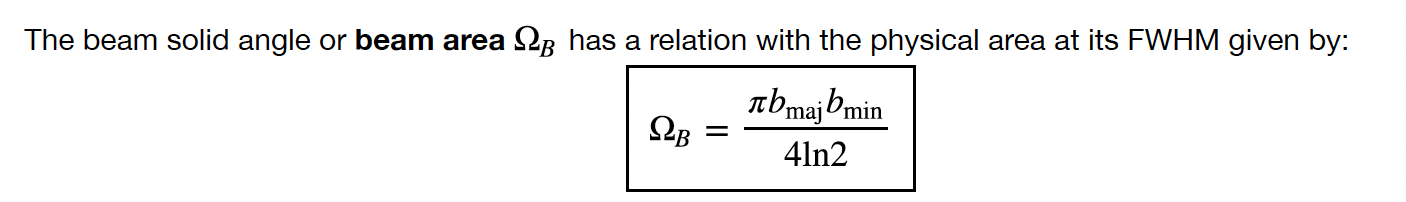

Do not forget that we need to convert bmin and bmaj into pixel size that we calculated before!

* From the spectrum, measure:
   * the recessional velocity of the galaxy
   * the velocity linewidth at 50% of the peak flux
   * the redshift
   * the luminosity distance, with H0 = 70 km/s/Mpc
   * plot vsys

In [ ]:
channel_width = abs(cdelt3) #take the positive value of your channel width
pix = abs(cdelt2)*3600 #Measure pixel size in arcseconds

# TODO: Get the spectral axis from your cube (Use SpectralCube.spectral_axis)
vel_axis = cube3D.XXXXX.to(u.km/u.s)

#flux density values in Jy/beam
# HINT: Sum over the spatial axes of the data cube [Z, Y, X]
flux_jy_beam = cube3D.sum(axis=(X,X)).value

#Beam area:
FWHM = np.pi/(4*np.log(2))
beam_area =  #arcsec^2 to pixel square
flux = flux_jy_beam / beam_area

#Other useful parameters:
velocity = vel_axis.value
# TODO: Define a threshold: 50% of the peak flux
threshold = 
# TODO: Create a mask of where the flux is above the threshold
mask = 
#Linewidth and systemic velocity
w50 = abs(velocity[mask][-1] - velocity[mask][0])
vsys = 0.5 * (velocity[mask][-1] + velocity[mask][0])
#Redshift
z = 

# Assume Hubble flow for distance:
H0 = 70  # km/s/Mpc
D =   # Mpc

print(f"W50: {w50:.1f} km/s, Vsys: {vsys:.1f} km/s, z: {z:.4f}, D: {D:.2f} Mpc")

In [ ]:
fig = plt.figure(figsize=(6.5,5.), dpi=100)
# TODO: Plot the flux as a function of velocity, solid line with linewidth of 1, black color)
plt.plot(________, ________, c='___', lw=__)
# TODO: Label the x- and y-axes
plt.xlabel("___________________")
plt.ylabel("___________________")
# OPTIONAL: Add a horizontal line at y=0 to mark the baseline
plt.axhline(y=___, c='___', lw=___, ls='___')

# TODO: Add a vertical line at the systemic velocity
# Hint: use your calculated vsys variable
plt.axvline(x=_______, c='___', lw=__, ls='___', label=f'V_sys = {vsys:.0f} km/s')
plt.legend(loc='best')
plt.show()

# <font color='purple'> 4-Measuring the local noise

* Noise is varying locally and spectrally
* To measure the mean noise around a galaxy, there are several methods. But here I am showing that a noise cube has been extracted just adjacent to the galaxy. An emission-free region, of the same size as the data cube. 
* Knowing the Root mean square (RMS) value is useful for distinguishing the emission from the noise, for making moment maps, and for measuring HI masses and integrated fluxes.
* To do so:
   * Open the noise file that has been sent to you
   * calculate the standard deviation along the two spatial axes (Y and X) for each spectral channel separately.
   * Take the mean value
* Create a masked cube at 4 sigma RMS

In [ ]:
#RMS CALCULATION IN THE NOISE CUBE
# TODO: Provide the path to your noise cube
noise_path = '_____'
# TODO: Read the noise cube using SpectralCube
noise_subcube = 

# TODO: Compute the standard deviation along the spatial axes (for each channel)
# Divide by the unit to remove units temporarily for computation
x = noise_subcube.XXXX(axis=(X,X))/noise_subcube.XXXX #getting the std for each channel
# TODO: Take the mean RMS value across all channels
mean_rms = np.XXXX(x) #in Jy
print(f"Mean RMS noise: {mean_rms*1e3:.2f} mJy")

# TODO: Create a masked cube keeping only values greater than 4 × mean RMS
masked_cube = cube3D.with_mask(XXXXX > XXXX*cube3D.unit)

# TODO: Save the masked cube (optional)
# masked_cube.write('_________________', overwrite=____)

# <font color='purple'> 5-Make channel maps

Let's plots each map per channel to visualize the detection and take note of the channel in which it appears

In [ ]:
# Put all velocity slices
channels = list(range(cube3D.shape[0]))
# Grid layout: e.g., 5 rows × 8 columns
nrows, ncols = 5, 8
fig, axs = plt.subplots(nrows, ncols, figsize=(16, 10))

for i, ch in enumerate(channels):
    row = i // ncols #getting the column index
    col = i % ncols
    ax = axs[row, col]
    
    img = cube3D[ch, :, :].value
    ax.imshow(img, origin='lower', cmap='viridis', norm=simple_norm(img, 'linear'))
    ax.set_title(f"Ch {ch}", fontsize=8)
    ax.axis('off')  # hide ticks

plt.tight_layout()
plt.show()

# <font color='purple'> 6-Make Moment maps

The step I have shown above for masking has been slightly simplified. Let's only select the channel at which the emission is happening. 

* Moment maps are straightforward in SpectralCube. 
* Use WCS coordinates to show the coordinates of the galaxy
* Moment maps can also be written into FITS files
* Add beam size as an ellipse at the bottom of each image.
* Calculate integrated fluxes and HI masses

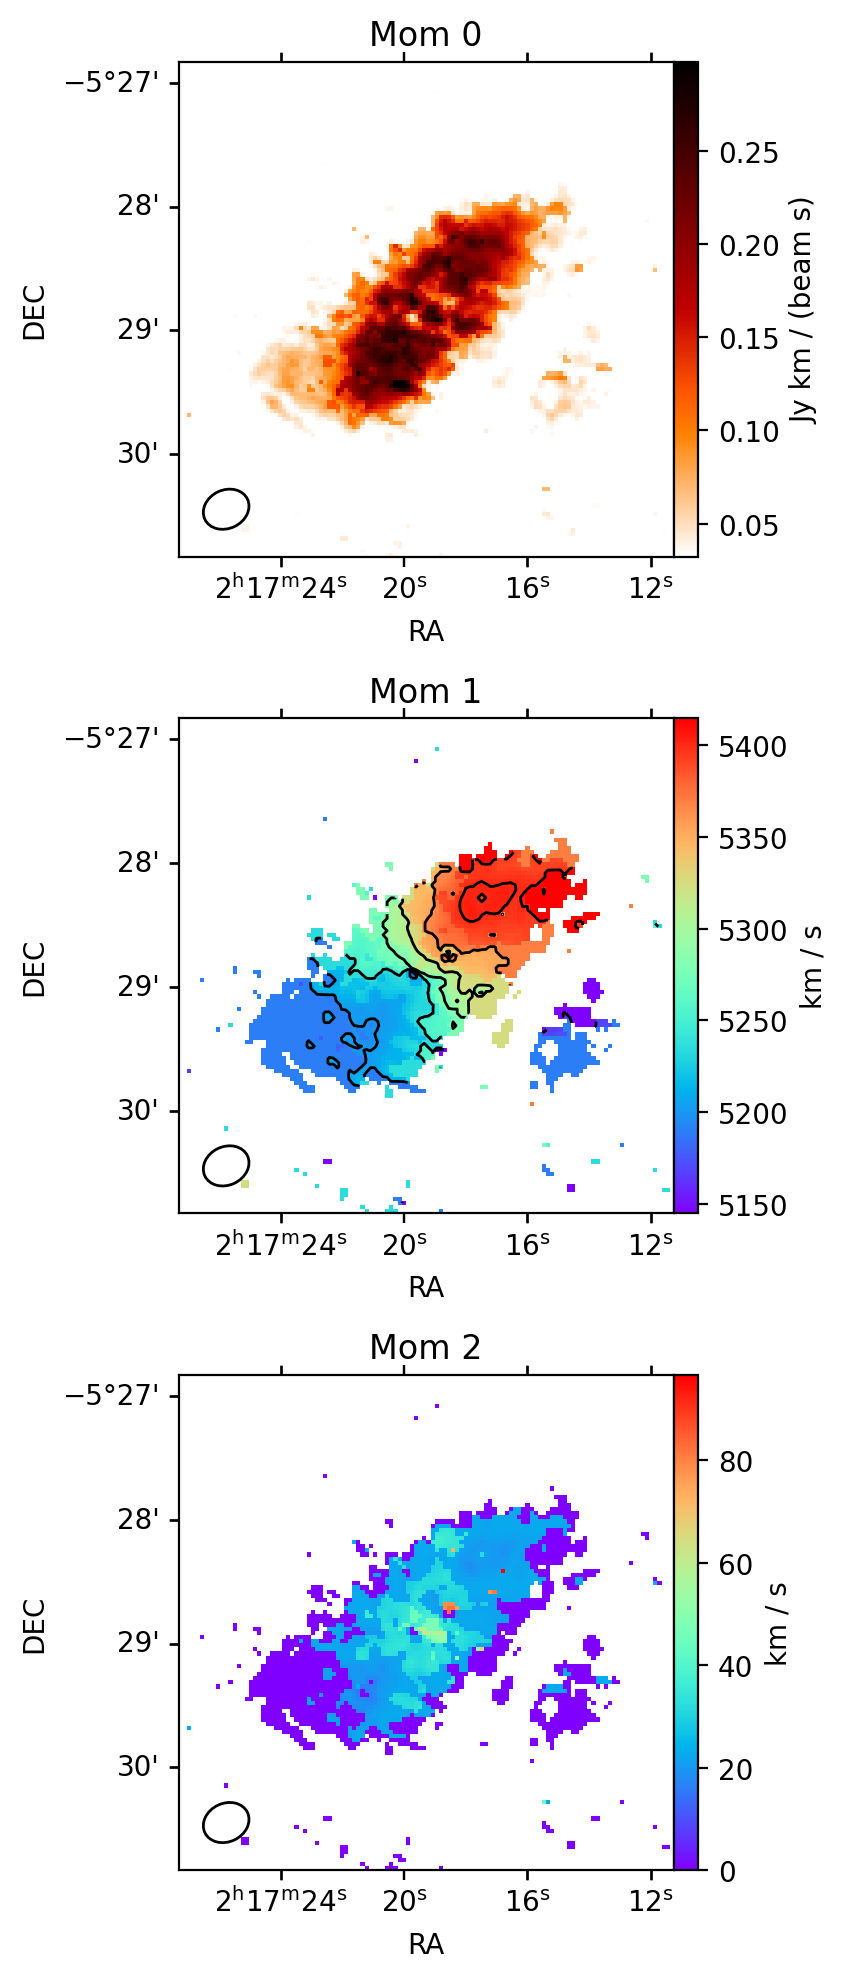

In [369]:
# ---------------------------
#  MOMENT MAPS
# ---------------------------

chan_a = 
chan_b = 
masked_cube2 = masked_cube[chan_a:chan_b+1]

# Get WCS projection for celestial coordinates from the header
wcs = WCS(____).celestial


# Calculate moment maps
mom0 = masked_cube2.____()     # 0th moment = integrated intensity
mom1 = masked_cube2.____()     # 1st moment = velocity field
mom2 = masked_cube2.____()     # 2nd moment = velocity dispersion (use linewidth_sigma)

#mom0.write('mom0.fits', overwrite=True)
#mom1.write('mom1.fits', overwrite=True)
#mom2.write('mom2.fits', overwrite=True)

# Set up subplots with WCS projection
fig, axes = plt.subplots(3, 1, figsize=(10, 10), subplot_kw={'projection': XXX}, dpi=200)

# Define the beam ellipse parameters (beam major/minor axes and position angle)
ellipse = Ellipse(
    xy=(11, 11), 
    width=____,        # beam major axis size in pixels or arcsec
    height=____,       # beam minor axis size
    edgecolor='k', 
    fc='None', 
    lw=1, 
    angle= -____      # beam position angle (anticlockwise)
)

# Plot Moment 0: Integrated intensity
im0 = axes[0].imshow(mom0.value, origin='lower', cmap='gist_heat_r')
axes[0].set_title('Mom 0')
axes[0].set_xlabel('RA')
axes[0].set_ylabel('DEC')
fig.colorbar(im0, ax=axes[0], orientation='vertical', 
             label=str(mom0.unit), pad=0)
axes[0].add_patch(ellipse)

# Plot Moment 1: Velocity field
im1 = axes[1].imshow(mom1.value, origin='lower', cmap='rainbow')
axes[1].set_title('Mom 1')
axes[1].set_xlabel('RA')
axes[1].set_ylabel('DEC')
axes[1].contour(mom1.value, colors='k',linewidths=1)
fig.colorbar(im1, ax=axes[1], orientation='vertical', 
             label=str(mom1.unit), pad=0)
ellipse = Ellipse(xy=(11, 11), width=bmaj, height=bmin, 
                        edgecolor='k', fc='None', lw=1,angle=-bpa) #Anti-clockwise
#copy ellipse here again, otherwise will encounter error
#axes[1].add_patch(ellipse)

# Plot Moment 2: Velocity dispersion
im2 = axes[2].imshow(mom2.value, origin='lower', cmap='rainbow')
axes[2].set_title('Mom 2')
axes[2].set_xlabel('RA')
axes[2].set_ylabel('DEC')
fig.colorbar(im2, ax=axes[2], orientation='vertical', 
             label=str(mom2.unit), pad=0)
ellipse = Ellipse(xy=(11, 11), width=bmaj, height=bmin, 
                        edgecolor='k', fc='None', lw=1,angle=-bpa) #Anti-clockwise
#copy ellipse here again, otherwise will encounter error
#axes[2].add_patch(ellipse)

plt.tight_layout()

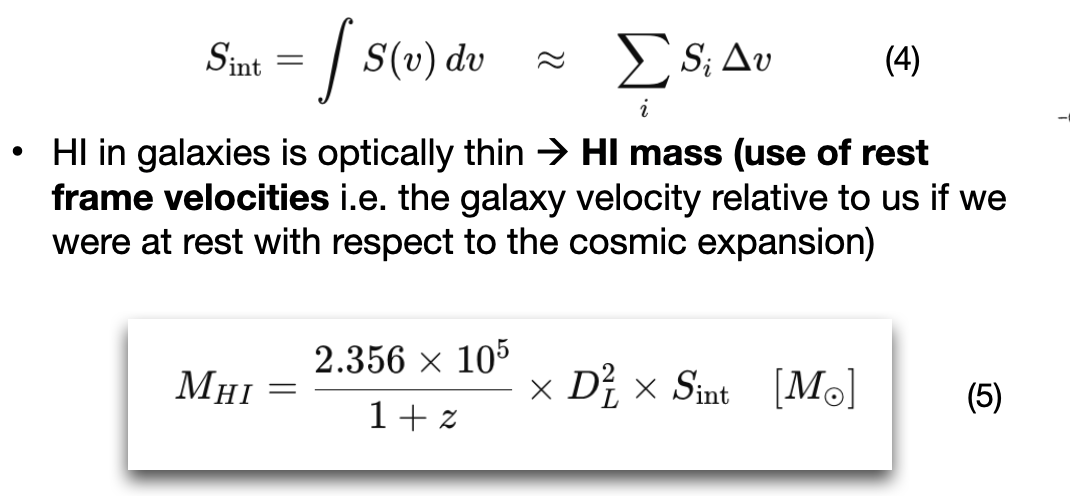

In [ ]:
# ---------------------------
# FLUXES AND HI MASS
# ---------------------------

# TODO: Find the peak flux from the flux array, avoid NaNs
peak_flux = 

# TODO: Calculate the integrated flux (Sint) from the moment 0 map,
# dividing by the beam area to convert from Jy/beam km/s to Jy km/s
Sint =    # Jy km/s

# TODO: Compute the HI mass using the formula below
M_HI = 2.356e5 * ___________ # M_sun

print(f"Peak flux: {peak_flux:.3f} Jy")
print(f"Integrated flux: {Sint:.3f} Jy km/s")
print(f"log HI mass: {np.log10(M_HI):.2f} M_sun")

# <font color='purple'> 7-Convert channel maps to GIF

* Make a GIF image from the channel maps where the emission starts and end
* Put noise contours
* Put velocity channels

In [ ]:
# TODO: Create a list of channels from chan_a to chan_b inclusive
channels = list(range(XXXXX, XXXXX + 1))


# TODO: Create subplots grid with 2 rows and 4 columns, figure size 14x6
fig, axs = plt.subplots(XXXXX, XXXXX, figsize=(14, 6))
plt.subplots_adjust(hspace=0.01, wspace=-0.4)

# Contour levels based on mean_rms (3, 5, and 7 sigmas)
levels = [mean_rms * f for f in [XXXX]]

for i, ch in enumerate(channels):
    row = i // 4
    col = i % 4
    ax = axs[row, col]
    # TODO: Extract 2D image slice for channel ch
    img = cube3D[XXXXX, :, :].value

    #Normalize image linearly for display
    norm = simple_norm(img, 'linear')

    # TODO: Display the image with 'plasma' colormap and normalization
    ax.imshow(XXXX, origin='lower', XXXXX='plasma', norm=norm)

    # Overplot contours with white contour
    ax.contour(XXX, levels=XXXX, XXXX='XXXX', linewidths=0.8)

    # Add velocity in top-left corner
    v = velocity[ch]
    ax.text(0.05, 0.95, f"{v:.1f} km/s", color='white', fontsize=9,
            transform=ax.transAxes, va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
    ax.axis('off')

# Hide unused subplot if total plots < 8
if len(channels) < 8:
    axs[1, 3].axis('off')

In [455]:
# ---------------------------
# BONUS: GIF OF CHANNELS
# ---------------------------
channels = list(range(chan_a, chan_b + 1))
images = []
for ch in range(chan_a, chan_b+1):
    fig, ax = plt.subplots()
    ax.imshow(cube3D[ch, :, :].value, cmap='plasma', origin='lower')
    ax.contour(cube3D[ch, :, :].value, levels=levels, colors='white', linewidths=0.8)
    v = velocity[ch]
    ax.text(0.05, 0.95, f"{v:.1f} km/s", color='white', fontsize=10,
            transform=ax.transAxes, va='top', ha='left',
            bbox=dict(boxstyle='round', facecolor='black', alpha=0.5))
    plt.axis('off')
    fig.canvas.draw()
    fname = f"frame_{ch:03d}.png"
    fig.savefig(fname)
    plt.close()
    images.append(imageio.imread(fname))

#duration in milliseconds
#To do: play with different durations
imageio.mimsave('channel_movie.gif', images, duration=XXXXX)

# Optional: delete frames after using for GIF.
for fname in [f"frame_{ch:03d}.png" for ch in channels]:
    os.remove(fname)